<a href="https://colab.research.google.com/github/OrianaForciniti/MATE-II/blob/main/26_08_polinomio_Taylor_incompleta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01a - Polinomio de Taylor
---

# Importamos librerías

In [ ]:
import numpy as np #para manejar arreglos
from matplotlib import pyplot as plt #para graficar
import math #contiene el factorial

plt.rcParams["figure.figsize"] = (10,7) #tamaño de los gráficos: ancho x alto

# Calcular un polinomio de Taylor y graficarlo junto con la función

## Objetivo: graficar $f(x)=\text{e}^x$ y sus polinomios de Taylor en un mismo gráfico, con $x_0 = 0$, para $x$ entre -2 y 2, y para órdenes 1, 2 y 3.

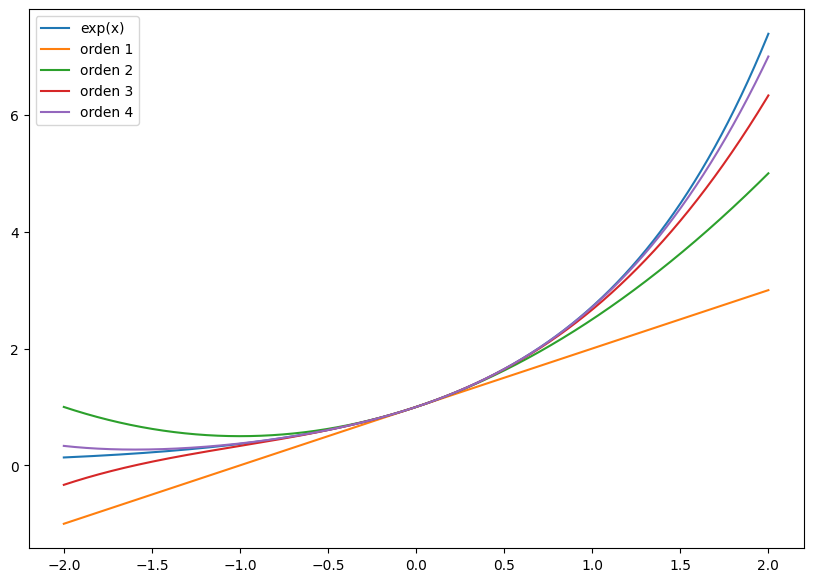

In [ ]:
# math.factorial(3) #factorial

def func(x):
  y = np.exp(x)
  return y

# defino pols de taylor
def pol_taylor1(x,a):                          #polinomio de orden uno
    y = np.exp(a) + np.exp(a)*(x-a)
    return y

#COMPLETAR: definir pols Taylor orden 2 y 3.


# defino vectores de X y de Y para graficar
valores_x = np.linspace(-2,2,10000)

valores_y = func(valores_x)
valores_taylor1 = pol_taylor1(valores_x, 0)    # Ese cero representa el Xo

# COMPLETAR: crear valores de Y para pols Taylor orden 2 y 3


# grafico
plt.plot(valores_x, valores_y, label="exp(x)")
plt.plot(valores_x, valores_taylor1, label="orden 1")
plt.legend()                                                          #Analisis de grafico :
#                                 En Xo tiene que valer lo mismo y alrededor tiene que parecerse
#                                 El polinomio de orden 1 siempre es una RECTA (Y tiene que pasar por el Xo)



# COMPLETAR graficar pols taylor orden 2 y 3.


# taylor   orden 2
def pol_taylor2(x,a):
  y = np.exp(a) + np.exp(a)*(x-a) + (np.exp(a)/2)*(x-a)**2
  return y

valores_y_2 = func(valores_x)
valores_taylor2 = pol_taylor2 (valores_x, 0)

plt.plot(valores_x, valores_taylor2, label="orden 2")
plt.legend()



# taylor   orden 3
def pol_taylor3(x,a):
  y = np.exp(a) + np.exp(a)*(x-a) + (np.exp(a)/2)*(x-a)**2 + (np.exp(a)/math.factorial(3))*(x-a)**3
  return y

valores_y_3 = func(valores_x)
valores_taylor3 = pol_taylor3 (valores_x, 0)

plt.plot(valores_x, valores_taylor3, label="orden 3")
plt.legend()




# taylor   orden 4
def pol_taylor4(x,a):
  y = np.exp(a) + np.exp(a)*(x-a) + (np.exp(a)/2)*(x-a)**2 + (np.exp(a)/math.factorial(3))*(x-a)**3 + (np.exp(a)/math.factorial(4))*(x-a)**4
  return y

valores_y_4 = func(valores_x)
valores_taylor4 = pol_taylor4 (valores_x, 0)

plt.plot(valores_x, valores_taylor4, label="orden 4")
plt.legend()








## para hacer ZOOM
#plt.ylim(-0.5,2)
#plt.xlim(-0.5,1)

# Chequear errores

## Objetivo: usar los polinomios de Taylor anteriores para aproximar $\text{e}^{0.1}$. Para cada órden inspeccionar el error que se está cometiendo.

In [ ]:
from logging import error
# la comida va aquí..
b = 0.1
print(np.exp(b)) # valor posta

print("orden 1:",pol_taylor1(b,0)) #aprox a orden 1, centrado en Xo = 0
print("orden 2:",pol_taylor2(b,0)) #aprox a orden 2, centrado en Xo = 0
print("orden 3:",pol_taylor3(b,0)) #aprox a orden 3, centrado en Xo = 0
print("orden 4:",pol_taylor4(b,0)) #aprox a orden 4, centrado en Xo = 0
print("Se observa que los primeros 3 numeros dsp de la coma son iguales al POSTA. Y a partir de él la aproximaciones difieren al real ")

########################## errores    ---->    Resto = f(x) - Pn(x)    ----> (como el valor puede ser negativo) para informar el error tiene que tener modulo

valor_posta = np.exp(b)
aprox_orden1 = pol_taylor1(b,0)
aprox_orden2 = pol_taylor2(b,0)
aprox_orden3 = pol_taylor3(b,0)
aprox_orden4 = pol_taylor4(b,0)

error_orden1 = abs(valor_posta - aprox_orden1)  # para obtener los modulos usar abs()
error_orden2 = valor_posta - aprox_orden2
error_orden3 = valor_posta - aprox_orden3
error_orden4 = valor_posta - aprox_orden4

print("error orden 1:",error_orden1)
print("error orden 2:",error_orden2)
print("error orden 3:",error_orden3)
print("error orden 4:",error_orden4)
print("Se cumple que a medida que el grado aumenta, el error disminuye")

# COMPLETAR: imprimir las aproximaciones a órdenes 2 y 3. ¿Qué observa?


1.1051709180756477
orden 1: 1.1
orden 2: 1.105
orden 3: 1.1051666666666666
orden 4: 1.1051708333333332
Se observa que los primeros 3 numeros dsp de la coma son iguales al POSTA. Y a partir de él la aproximaciones difieren al real 
error orden 1: 0.005170918075647624
error orden 2: 0.0001709180756477302
error orden 3: 4.2514089810818945e-06
error orden 4: 8.474231449895342e-08
Se cumple que a medida que el grado aumenta, el error disminuye


# Averiguar el orden para que el error sea menor a uno deseado

## Objetivo: acotar el resto de Taylor para $f(x)=\text{e}^x$ con $x_0 = 0$, y encontrar el órden (el $n$) para asegurar que el error cometido al aproximar $\text{e}^{0.1}$ sea menor a $10^{-8}$.

In [ ]:
# primero hacer a mano. Recordar que el objetivo es aproximar exp(0.1)

cota_theta = 3  # -------------------------------------------------> ver cuentas cuaderno ----------> elegimos trabajar con 3 pq es > al del cuaderno
#Definicion de funcion para calcular error
def error_max(n):
  numerador = cota_theta * 0.1**(n+1)     # 3 es la cota para theta
  denominandor = math.factorial(n+1)
  error = abs(numerador/denominandor)
  return error

# El error para cuando n = 1
print("Error orden 1")
print(error_max(1))
print("como el valor obtenido es mayor al error de orden 1 antes calculado, la cota funciona")

error_orden_1 = error_max(1)

#Error para un n general   ---> que cumpla la condicion del WHILE
error_actual = error_orden_1
n_actual = 1
while error_actual > 10**(-8):
  error_orden_siguiente = error_max(n_actual + 1)

  error_actual = error_orden_siguiente

  n_actual = n_actual + 1

  print(f"Orden {n_actual}") #entre llaves puedo traer una variable, pero para eso poner una f antes de las "comillas"
  print(error_actual)


#error_max(0)
# definir una función que calcular el error de taylor dado un órden


# con un while aumentar el órden hasta que el error sera menor o igual
# a un número chico


Error orden 1
0.015000000000000003
como el valor obtenido es mayor al error de orden 1 antes calculado, la cota funciona
Orden 2
0.0005000000000000001
Orden 3
1.25e-05
Orden 4
2.5000000000000004e-07
Orden 5
4.1666666666666676e-09


# Ejercicio
##- Graficar $f(x)=\ln(x)$ para $x$ entre 0.1 y 2.
##- Graficar los pols. de Taylor de órdenes 1, 2 y 3 con $x_0=1$ junto a la función.
##- Aproximar $\ln(1.1)$ y ver el error que se está cometiendo para cada órden.
##- Acotar el resto de Taylor y encontrar el órden para asegurar que el error sea menor a $10^{-10}$

error orden 1: 0.004689820195675154
error orden 2: 0.0003101798043248505
error orden 3: 2.3153529008487772e-05
error para orden 1: 0.050000000000000086
error para orden 2: 0.0016666666666666711
error para orden 3: 4.1666666666666814e-05
Orden 1
0.050000000000000086
El orden que debo usar es 7 porque el error que calculó es menor a 10**(-10)
Orden 2
0.0016666666666666711
El orden que debo usar es 7 porque el error que calculó es menor a 10**(-10)
Orden 3
4.1666666666666814e-05
El orden que debo usar es 7 porque el error que calculó es menor a 10**(-10)
Orden 4
8.333333333333371e-07
El orden que debo usar es 7 porque el error que calculó es menor a 10**(-10)
Orden 5
1.3888888888888963e-08
El orden que debo usar es 7 porque el error que calculó es menor a 10**(-10)
Orden 6
1.9841269841269962e-10
El orden que debo usar es 7 porque el error que calculó es menor a 10**(-10)
Orden 7
2.4801587301587477e-12
El orden que debo usar es 7 porque el error que calculó es menor a 10**(-10)


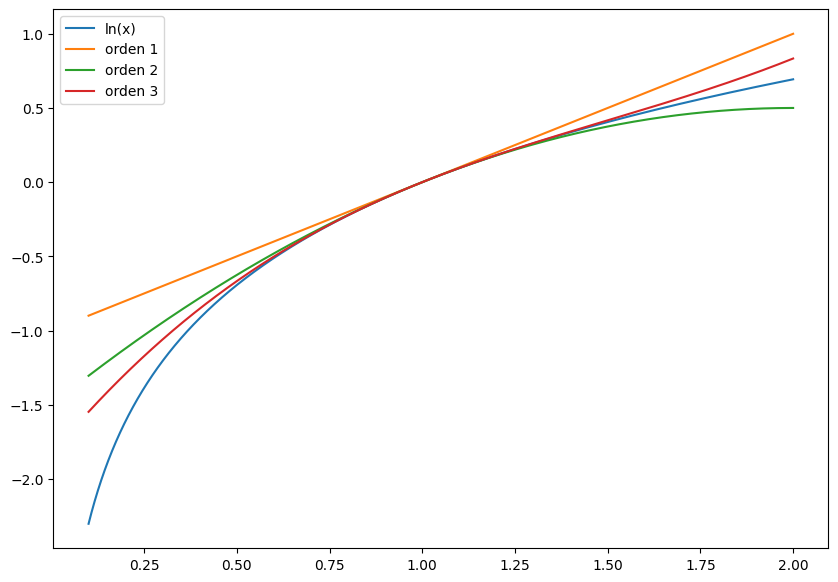

In [ ]:
# np.log(x) # es el logaritmo natural

def func(x):
  y = np.log(x)
  return y

valores_x_log = np.linspace(0.1,2,10000)

valores_y_log = func(valores_x_log)

plt.plot(valores_x_log, valores_y_log, label="ln(x)")
plt.legend()


a = 1
def pol_taylor1_log(x,a):                          #polinomio de orden uno
    y1 = np.log(a) + 1/(a)*(x-a)
    return y1

valores_y_taylor1_log = pol_taylor1_log(valores_x_log, a)
plt.plot(valores_x_log, valores_y_taylor1_log, label="orden 1")
plt.legend()

def pol_taylor2_log(x,a):
  y = pol_taylor1_log(x,a) + ((-1)*a**(-2)/math.factorial(2))*(x-a)**2  #si queres traer el polinomio de arriba tener que hacerlo cin las variables
  return y

valores_y_taylor2_log = pol_taylor2_log(valores_x_log,a)
plt.plot(valores_x_log, valores_y_taylor2_log, label="orden 2")
plt.legend()

def pol_taylor3_log(x,a):
  y = pol_taylor2_log(x,1) + (2*a**(-3)/math.factorial(3))*(x-a)**3
  return y

valores_y_taylor3_log = pol_taylor3_log(valores_x_log,a)
plt.plot(valores_x_log, valores_y_taylor3_log, label="orden 3")
plt.legend()

valor_real = func(1.1)
# print(valor_real)

##ITEM 3 APROXIMAR EL POLINOMIO EN X=1.1, Y VER CUANTO DIFIERE DE LA FUNCION

ERROR1 = abs(valor_real - pol_taylor1_log(1.1,1))
ERROR2 = abs(valor_real - pol_taylor2_log(1.1,1))
ERROR3 = abs(valor_real - pol_taylor3_log(1.1,1))

print("error orden 1:",ERROR1)
print("error orden 2:",ERROR2)
print("error orden 3:",ERROR3)

##########################################################
cota_theta = 10
x= 1.1
def error_max(n):
  numerador = cota_theta * (x - a)**(n+1)     # 3 es la cota para theta
  denominandor = math.factorial(n+1)
  error = abs(numerador/denominandor)
  return error

print("error para orden 1:", error_max(1))
print("error para orden 2:", error_max(2))
print("error para orden 3:", error_max(3))




########################################



n = 0
while error_max(n) >= 10**(-10):
  n = n + 1
  print(f"Orden {n}")
  print(error_max(n))
  print("El orden que debo usar es 7 porque el error que calculó es menor a 10**(-10)")

# Ejercicios 4, 6 y 8 de la P1.